In [27]:
!pip install -q kagglehub

In [28]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "nandeeshhu/pancrease-ct-segmenatation"
)

print(dataset_path)

Using Colab cache for faster access to the 'pancrease-ct-segmenatation' dataset.
/kaggle/input/pancrease-ct-segmenatation


In [29]:
import os

images_path = os.path.join(
    dataset_path,
    "images",
    "positive"
)

masks_path = os.path.join(
    dataset_path,
    "masks",
    "positive"
)

print("Images:", len(os.listdir(images_path)))
print("Masks :", len(os.listdir(masks_path)))

Images: 6882
Masks : 6882


In [30]:
image_files = sorted(os.listdir(images_path))
mask_files = sorted(os.listdir(masks_path))

image_paths = [
    os.path.join(images_path, f)
    for f in image_files
]

mask_paths = [
    os.path.join(masks_path, f)
    for f in mask_files
]

print("Image Pairs:", len(image_paths))
print("Mask Pairs :", len(mask_paths))

Image Pairs: 6882
Mask Pairs : 6882


In [31]:
print(image_files[0])
print(mask_files[0])

print(image_files[100])
print(mask_files[100])

img_00099.png
mask_00099.png
img_00332.png
mask_00332.png


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 5505
Test : 1377


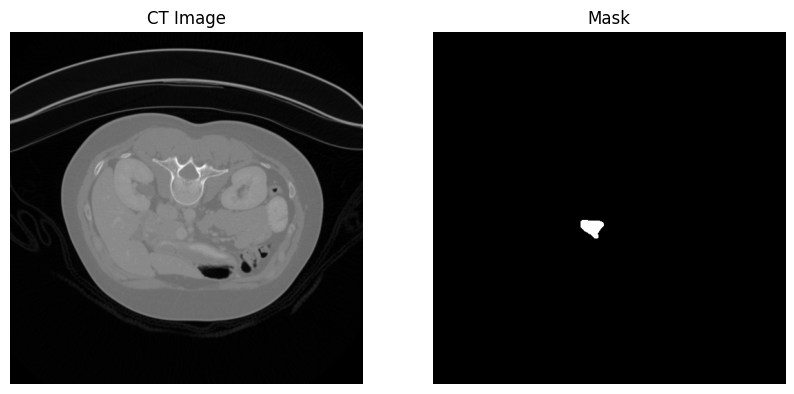

In [33]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(X_train[0])
mask = Image.open(y_train[0])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("CT Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [34]:
import tensorflow as tf

IMG_SIZE = 256

def process_pair(image_path, mask_path):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    mask = tf.io.read_file(mask_path)

    mask = tf.image.decode_png(
        mask,
        channels=1
    )

    mask = tf.image.resize(
        mask,
        [IMG_SIZE, IMG_SIZE],
        method="nearest"
    )

    mask = tf.cast(
        mask,
        tf.float32
    ) / 255.0

    return image, mask

In [35]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

train_ds = train_ds.map(
    process_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    process_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(16).prefetch(
    tf.data.AUTOTUNE
)

test_ds = test_ds.batch(16).prefetch(
    tf.data.AUTOTUNE
)

print("U-Net dataset ready")

U-Net dataset ready


In [36]:
for images, masks in train_ds.take(1):

    print("Images :", images.shape)

    print("Masks  :", masks.shape)

    print("Mask Min:", tf.reduce_min(masks).numpy())

    print("Mask Max:", tf.reduce_max(masks).numpy())

Images : (16, 256, 256, 1)
Masks  : (16, 256, 256, 1)
Mask Min: 0.0
Mask Max: 1.0


In [37]:
from tensorflow.keras import layers
from tensorflow.keras import Model

inputs = layers.Input((256,256,1))

# Encoder
c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
p1 = layers.MaxPooling2D((2,2))(c1)

c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
p2 = layers.MaxPooling2D((2,2))(c2)

# Bottleneck
b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(b1)

# Decoder
u1 = layers.UpSampling2D((2,2))(b1)
u1 = layers.Concatenate()([u1, c2])

c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

u2 = layers.UpSampling2D((2,2))(c3)
u2 = layers.Concatenate()([u2, c1])

c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)
c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

outputs = layers.Conv2D(
    1,
    1,
    activation='sigmoid'
)(c4)

unet_model = Model(inputs, outputs)

unet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 256, 256,  │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 256, 256,  │      2,320 │ conv2d_11[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_13[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 128, 128,  │          0 │ conv2d_16[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 96)               │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │     27,680 │ concatenate_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_17[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 256, 256,  │          0 │ conv2d_18[0][0]   │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256, 256,  │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 48)               │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │      6,928 │ concatenate_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │      2,320 │ conv2d_19[0][0] 

 Total params: 117,985 (460.88 KB)

 Trainable params: 117,985 (460.88 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
def dice_coefficient(y_true, y_pred):

    smooth = 1e-6

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(
        y_true_f * y_pred_f
    )

    return (
        2. * intersection + smooth
    ) / (
        tf.reduce_sum(y_true_f)
        + tf.reduce_sum(y_pred_f)
        + smooth
    )

In [39]:
unet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        dice_coefficient
    ]
)

print("U-Net compiled.")

U-Net compiled.


In [40]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42
)

print("Train      :", len(X_train_final))
print("Validation :", len(X_val))
print("Test       :", len(X_test))

Train      : 4954
Validation : 551
Test       : 1377


In [41]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_final, y_train_final)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

train_ds = train_ds.map(
    process_pair,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(16).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(
    process_pair,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(16).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(
    process_pair,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(16).prefetch(tf.data.AUTOTUNE)

print("Train/Val/Test datasets ready")

Train/Val/Test datasets ready


In [42]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [43]:
history = unet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 51s 136ms/step - dice_coefficient: 0.0232 - loss: 0.0388 - val_dice_coefficient: 0.0355 - val_loss: 0.0228
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - dice_coefficient: 0.0548 - loss: 0.0199 - val_dice_coefficient: 0.0943 - val_loss: 0.0192
Epoch 3/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 38s 123ms/step - dice_coefficient: 0.1136 - loss: 0.0172 - val_dice_coefficient: 0.1776 - val_loss: 0.0161
Epoch 4/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 39s 117ms/step - dice_coefficient: 0.2089 - loss: 0.0145 - val_dice_coefficient: 0.2757 - val_loss: 0.0141
Epoch 5/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - dice_coefficient: 0.2860 - loss: 0.0128 - val_dice_coefficient: 0.3584 - val_loss: 0.0128
Epoch 6/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 40s 128ms/step - dice_coefficient: 0.3616 - loss: 0.0112 - val_dice_coefficient: 0.3833 - val_loss: 0.0109
Epoch 7/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - dice_coefficient: 0.4213 - loss: 0.0100 - val_dice_coefficien

In [44]:
unet_model.save("unet_bce.keras")

print("Saved BCE model")

Saved BCE model


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step


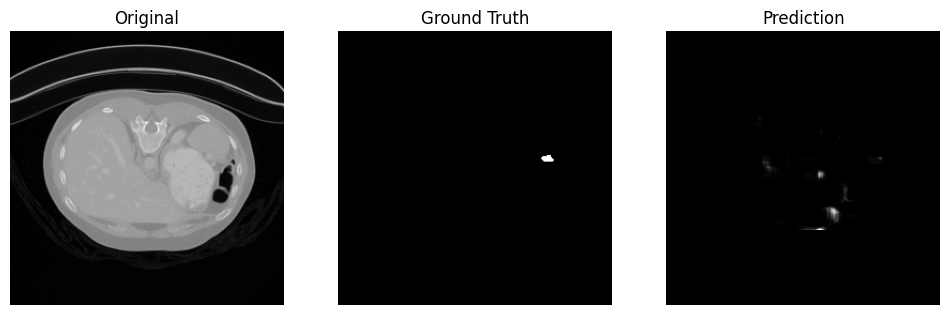

In [45]:
import matplotlib.pyplot as plt

for images, masks in test_ds.take(1):

    pred_masks = unet_model.predict(images)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(images[0].numpy().squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(masks[0].numpy().squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred_masks[0].squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

    break

In [46]:
unet_model.save("unet_bce.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


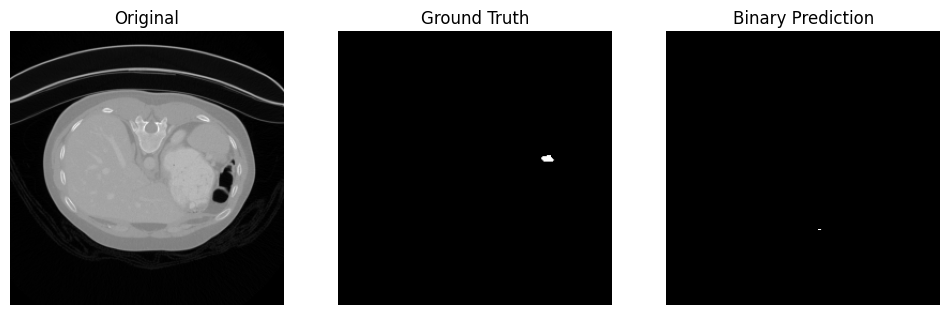

In [47]:
for images, masks in test_ds.take(1):

    pred_masks = unet_model.predict(images)

    pred_binary = (pred_masks > 0.5).astype("float32")

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(images[0].numpy().squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(masks[0].numpy().squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred_binary[0].squeeze(), cmap="gray")
    plt.title("Binary Prediction")
    plt.axis("off")

    plt.show()

    break

In [48]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

unet_model.compile(
    optimizer="adam",
    loss=dice_loss,
    metrics=[dice_coefficient]
)

In [49]:
unet_model.save("unet_bce.keras")

In [50]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

In [51]:
unet_model.compile(
    optimizer="adam",
    loss=dice_loss,
    metrics=[dice_coefficient]
)

In [52]:
history = unet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 44s 121ms/step - dice_coefficient: 0.6839 - loss: 0.3161 - val_dice_coefficient: 0.7070 - val_loss: 0.2927
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - dice_coefficient: 0.7193 - loss: 0.2808 - val_dice_coefficient: 0.7325 - val_loss: 0.2674
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - dice_coefficient: 0.7448 - loss: 0.2552 - val_dice_coefficient: 0.7476 - val_loss: 0.2530


In [53]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [54]:
history = unet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - dice_coefficient: 0.7165 - loss: 0.2835 - val_dice_coefficient: 0.7302 - val_loss: 0.2702
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - dice_coefficient: 0.7360 - loss: 0.2640 - val_dice_coefficient: 0.7121 - val_loss: 0.2884
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 35s 114ms/step - dice_coefficient: 0.7628 - loss: 0.2372 - val_dice_coefficient: 0.7617 - val_loss: 0.2386
Epoch 4/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - dice_coefficient: 0.7741 - loss: 0.2259 - val_dice_coefficient: 0.7574 - val_loss: 0.2428
Epoch 5/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - dice_coefficient: 0.7800 - loss: 0.2200 - val_dice_coefficient: 0.7631 - val_loss: 0.2372
Epoch 6/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - dice_coefficient: 0.7936 - loss: 0.2065 - val_dice_coefficient: 0.7762 - val_loss: 0.2237
Epoch 7/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - dice_coefficient: 0.8058 - loss: 0.1942 - val_dice_coefficien

In [55]:
unet_model.save("unet_final.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [56]:
import tensorflow as tf
import numpy as np

test_model = tf.keras.models.load_model(
    "unet_final.keras",
    compile=False
)

for images, masks in test_ds.take(1):

    pred = test_model.predict(images)

    print("Min:", pred.min())
    print("Max:", pred.max())
    print("Mean:", pred.mean())

    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step
Min: 0.0
Max: 1.0
Mean: 0.003349689


In [57]:
from google.colab import files

files.download("unet_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>